In [1]:
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas_datareader import data
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore', 'statsmodels.tsa.arima_model.ARMA', FutureWarning)

In [2]:
tickers = ['AAPL']

start_date = '2019-01-01'

today = datetime.date.today()
yesterday = today - datetime.timedelta(days=1)
end_date = yesterday

# User pandas_reader.data.DataReader to load data
panel_data = data.DataReader(tickers, 'yahoo', start_date, end_date)


# df = panel_data['Close']
df = panel_data
df.head()

Attributes,Adj Close,Close,High,Low,Open,Volume
Symbols,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2018-12-31,38.282616,39.435001,39.840000,39.119999,39.632500,140014000.0
2019-01-02,38.326294,39.480000,39.712502,38.557499,38.722500,148158800.0
2019-01-03,34.508705,35.547501,36.430000,35.500000,35.994999,365248800.0
2019-01-04,35.981861,37.064999,37.137501,35.950001,36.132500,234428400.0
2019-01-07,35.901775,36.982498,37.207500,36.474998,37.174999,219111200.0


In [3]:
# from sklearn.linear_model import LinearRegression

# model = LinearRegression()
# model.fit(training_data)

# Auto ARIMA

In [4]:
close = df['Close']
# splitting the data
train_ratio = 0.8
train_size = int(df.shape[0] * train_ratio)
test_size = df.shape[0] - train_size

train = close.head(train_size)
test = close.tail(test_size)

# train.plot()
# test.plot()

Testing Mean Squared Error is 45.46257774903891


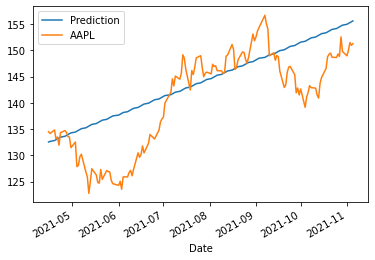

In [5]:
from pmdarima import auto_arima

model = auto_arima(train, start_p=1, start_q=1,max_p=6, max_q=3, m=12, seasonal=True, error_action='ignore',suppress_warnings=True)
model.fit(train)

forecast = model.predict(n_periods=test_size)
forecast = pd.DataFrame(forecast,index = test.index,columns=['Prediction'])
# forecast = pd.DataFrame(forecast,columns=['Prediction'])

result = pd.concat([forecast, test], axis = 1)
result.plot()

# calculating rms 
MSE_error = mean_squared_error(test, forecast)
print('Testing Mean Squared Error is {}'.format(MSE_error))

In [6]:
forecast

,Prediction
Date,
2021-04-15,132.541899
2021-04-16,132.655632
2021-04-19,132.823810
2021-04-20,132.984543
2021-04-21,133.146294
...,...
2021-11-01,154.966151
2021-11-02,155.127780
2021-11-03,155.289408


# ARIMA

In [7]:
from statsmodels.tsa.arima_model import ARIMA

train_data, test_data = df[0:int(len(df)*0.7)], df[int(len(df)*0.7):]
training_data = train_data['Close'].values
test_data = test_data['Close'].values
history = [x for x in training_data]
model_predictions = []
N_test_observations = len(test_data)
for time_point in range(N_test_observations+1):
    try:
        model = ARIMA(history, order=(4,1,0))
        model_fit = model.fit(disp=0)
        output = model_fit.forecast()
        yhat = output[0]
        true_test_value = test_data[time_point]
        history.append(true_test_value)
        model_predictions.append(yhat)
    except:
        today_stock_price = yhat
MSE_error = mean_squared_error(test_data, model_predictions)
print('Testing Mean Squared Error is {}'.format(MSE_error))

C:\Users\Admin\.conda\envs\is453\lib\site-packages\statsmodels\tsa\arima_model.py:472: FutureWarning: 
statsmodels.tsa.arima_model.ARMA and statsmodels.tsa.arima_model.ARIMA have
been deprecated in favor of statsmodels.tsa.arima.model.ARIMA (note the .
between arima and model) and
statsmodels.tsa.SARIMAX. These will be removed after the 0.12 release.

statsmodels.tsa.arima.model.ARIMA makes use of the statespace framework and
is both well tested and maintained.

To silence this warning and continue using ARMA and ARIMA until they are
removed, use:

import warnings
warnings.filterwarnings('ignore', 'statsmodels.tsa.arima_model.ARMA',
                        FutureWarning)
warnings.filterwarnings('ignore', 'statsmodels.tsa.arima_model.ARIMA',
                        FutureWarning)

  warnings.warn(ARIMA_DEPRECATION_WARN, FutureWarning)


Testing Mean Squared Error is 4.311092916141513


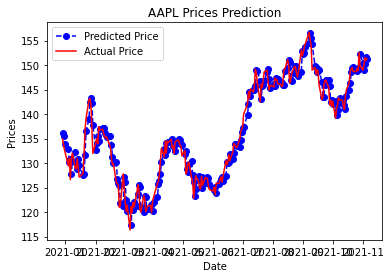

Today's price prediction:  151.33736003406227


In [8]:
test_set_range = df[int(len(df)*0.7):].index
plt.plot(test_set_range, model_predictions, color='blue', marker='o', linestyle='dashed',label='Predicted Price')
plt.plot(test_set_range, test_data, color='red', label='Actual Price')
plt.title('AAPL Prices Prediction')
plt.xlabel('Date')
plt.ylabel('Prices')
# plt.xticks(np.arange(881,1259,50), df.Date[881:1259:50])
plt.legend()
plt.show()


#future predictions
print("Today's price prediction: ", yhat[0])

# Prophet

In [9]:
from prophet import Prophet

Importing plotly failed. Interactive plots will not work.


In [11]:
close = df['Close']

#preparing data
close.reset_index(inplace = True)
close = close[['Date', 'AAPL']]
close.rename(columns={'AAPL': 'y', 'Date':'ds'}, inplace = True)

#splitting the data
train_ratio = 0.8
train_size = int(df.shape[0] * train_ratio)
test_size = df.shape[0] - train_size

train = close.head(train_size)
test = close.tail(test_size)

#fit the model
model = Prophet(daily_seasonality=True)
model.fit(train)

#predictions
close_prices = model.make_future_dataframe(periods=len(test))
forecast = model.predict(close_prices)

#rmse
forecast_valid = forecast['yhat'][-test_size:]
MSE_error = mean_squared_error(test['y'], forecast_valid)
print('Testing Mean Squared Error is {}'.format(MSE_error))

Testing Mean Squared Error is 107.17402333526385


C:\Users\Admin\AppData\Local\Temp/ipykernel_91716/3157086934.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = 0
C:\Users\Admin\AppData\Local\Temp/ipykernel_91716/3157086934.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = forecast_valid.values


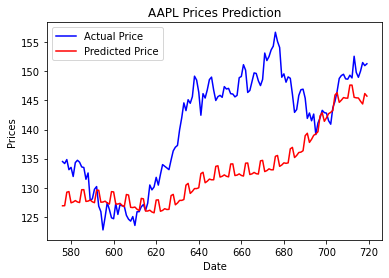

In [12]:
#plot
test['Predictions'] = 0
test['Predictions'] = forecast_valid.values

# plt.plot(train['y'])
plt.plot(test['y'], color = 'blue', label = 'Actual Price')
plt.plot(test['Predictions'], color = 'red', label = 'Predicted Price')
plt.title('AAPL Prices Prediction')
plt.xlabel('Date')
plt.ylabel('Prices')
plt.legend()
plt.show()

# LSTM

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM

In [ ]:
close = df['Close']

#preparing data
close.reset_index(inplace = True)
close = close[['Date', 'AAPL']]

#splitting the data
train_ratio = 0.8
train_size = int(df.shape[0] * train_ratio)
test_size = df.shape[0] - train_size

train = close.head(train_size)
test = close.tail(test_size)